### 보스턴 주택 가격 예측

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("../Data/boston.xlsx")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Column 설명
- CRIM : 지역별 범죄 발생률
- ZN : 25000평방 피트를 초과하는 거주 지역의 비율  
- INDUS : 비상업 지역 넓이 비율 
- CHAS : 찰스강에 대한 더미 변숙 (강의 경계에 위치한 경우는 1, 아니면 0) 
- NOX : 일산화 질수 농도
- RM : 거주할 수 있는 방 갯수
- AGE : 1940년 이전에 건축된 소유 주택의 비율
- DIS : 5개 주요 고용센터까지의 가중 거리 
- RAD : 고속도로 접근 용이도 
- TAX : 10000달러당 재산 세율 
- PTRATIO : 지역의 교사와 학생수 비율 
- B : 지역의 흑인 거주 비율
- LSTAT : 하위 계층의 비율 
- PRICE : 본인 소유의 주택 가격(중앙값)

In [3]:
# 데이터셋 크기
df.shape

(506, 14)

In [4]:
# 컬럼별 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
# 기본 통계량
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 상관 관계 분석

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

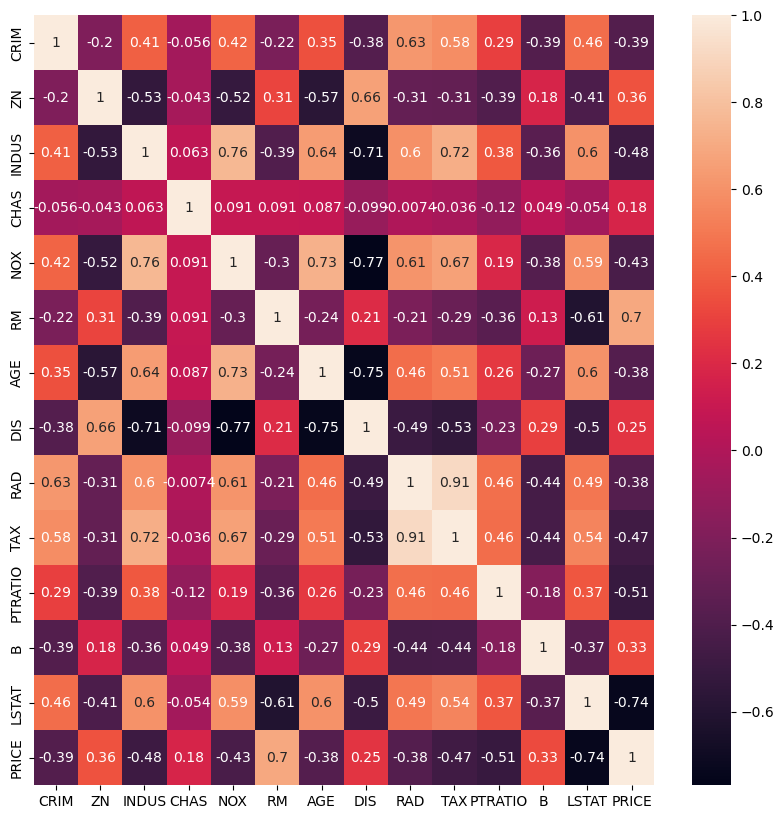

In [8]:
# 상관 관계 행렬
df_corr = df.corr()

# 히트맵
plt.figure(figsize=(10, 10))
sns.heatmap(
    df_corr,
    annot=True,
    cbar=True
)

plt.show()

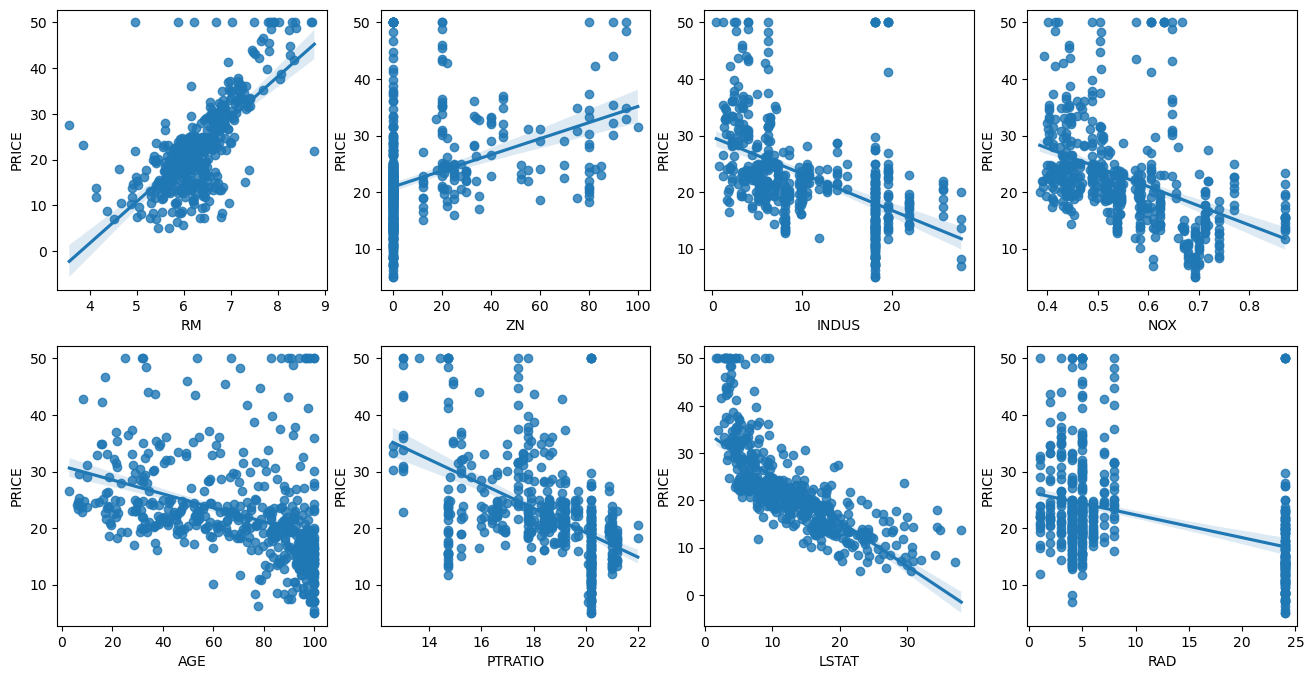

In [9]:
# PRICE와 각 컬럼의 회귀 직선
# 2 X 4 subplots 이용
fig, axs = plt.subplots(
                figsize=(16,8),
                ncols=4,
                nrows=2
)

lm_features = ['RM', 'ZN', 'INDUS', 'NOX', "AGE", "PTRATIO", "LSTAT", 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i/4) # row수(0과1)
    col = i % 4

    sns.regplot(
        x=feature,
        y='PRICE',
        data=df,
        ax=axs[row][col]
    )

> 집값 상승과 상관관계 best : RM(방갯수)     
집갑 하락과 상관관계 best : LSTAT(하위 계층 비율)

---
### 선형회귀 모델로 예측

In [10]:
# Feature와 Target으로 분리
y_target = df["PRICE"]
X_data = df.drop(["PRICE"], axis='columns')

In [12]:
print(y_target.shape)
print(X_data.shape)

(506,)
(506, 13)


In [13]:
# Train과 Test
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
                                        X_data,
                                        y_target,
                                        test_size=0.3,
                                        random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(354, 13)
(152, 13)
(354,)
(152,)


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
lr = LinearRegression()

In [18]:
lr.fit(X_train, y_train)

LinearRegression()

In [19]:
pred = lr.predict(X_test)
pred[:5]

array([28.64896005, 36.49501384, 15.4111932 , 25.40321303, 18.85527988])

### 평가전에 예측값과 정답을 그래프로 확인

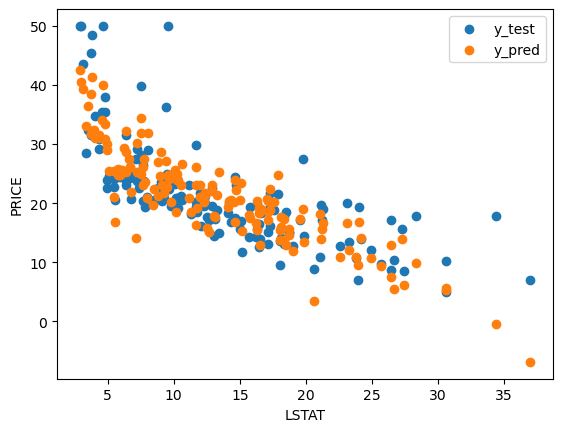

In [22]:
# LSTAT와 PRICE의 그래프를 이용해 예측값 출력
plt.scatter(
    X_test['LSTAT'],
    y_test,
    label = 'y_test'
)

plt.scatter(
    X_test['LSTAT'],
    pred,
    label = 'y_pred'
)

plt.xlabel('LSTAT')
plt.ylabel("PRICE")
plt.legend(loc='best')
plt.show()

### 평가
- MSE(Mean Square Error) : 평균 제곱 오차 
- RMSE(Root Mean Square Error) : 평균 제곱근 오차 

In [23]:
from sklearn.metrics import mean_squared_error, r2_score # 선형회귀모델 적합도 : 분산값, 1에 가까울수록 접합도 높다. 
import numpy as np

In [24]:
# RMSE를 이용한 평가
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(f"MSE : {mse:.3f}, RMSE : {rmse:.3f}")
print(f"Score : {r2_score(y_test, pred):.3f}")

MSE : 21.517, RMSE : 4.639
Score : 0.711


> score는 1에 가까울 수록 좋은 점수이다.   
약 71점 이고 오차는 4.6달러 정도 이다. 

In [25]:
# 절편값 확인하기
print('절편값 :', lr.intercept_)

절편값 : 31.631084035692727


In [27]:
# 회귀 계수 : 독립 변수의 영향에 따라 종속변수에 미치는 영향력 크기 
print("회귀계수 :", np.round(lr.coef_,1))

회귀계수 : [ -0.1   0.    0.    3.1 -15.4   4.1  -0.   -1.4   0.2  -0.   -0.9   0.
  -0.5]
